/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/590 [00:00<?, ?B/s]

data/train-00000-of-00006-336b26d54a26e1(…):   0%|          | 0.00/91.2M [00:00<?, ?B/s]

data/train-00001-of-00006-8ad2d550254dea(…):   0%|          | 0.00/25.9M [00:00<?, ?B/s]

data/train-00002-of-00006-ac8970f21c0418(…):   0%|          | 0.00/339M [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Using device: cpu
Creating train embeddings...
Creating validation embeddings...
Creating test embeddings...
Train shape: (2100, 768)
Validation shape: (450, 768)
Test shape: (450, 768)
k=1 | Validation F1=0.7473
k=3 | Validation F1=0.7670
k=5 | Validation F1=0.7569
k=7 | Validation F1=0.7489
k=9 | Validation F1=0.7552

Best k based on validation F1: 3

===== Validation Results =====
Accuracy:  0.7689
F1-score:  0.7670
Precision: 0.7775
Recall:    0.7689
PR-AUC:    0.8060

===== Test Results =====
Accuracy:  0.7911
F1-score:  0.7891
Precision: 0.7943
Recall:    0.7911
PR-AUC:    0.7720

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       242
           1       0.82      0.70      0.76       208

    accuracy                           0.79       450
   macro avg       0.80      0.78      0.79       450
weighted avg       0.79      0.79      0.79       450



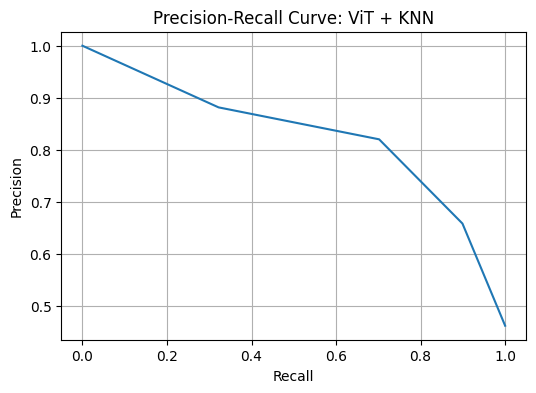

<Figure size 600x600 with 0 Axes>

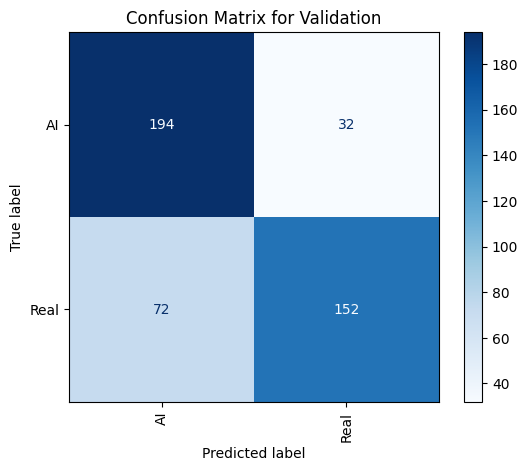

<Figure size 600x600 with 0 Axes>

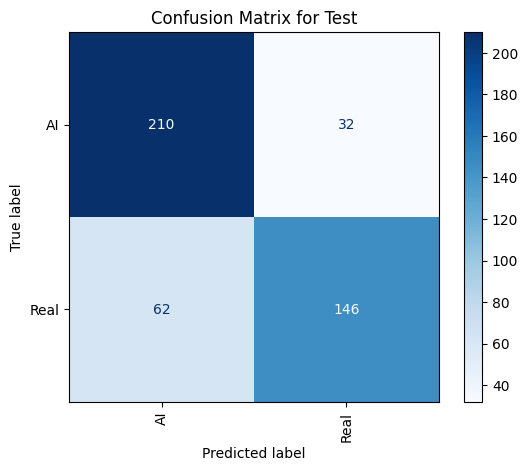

In [ ]:


!pip install -q datasets transformers scikit-learn pillow torch torchvision matplotlib

from datasets import load_dataset
from transformers import ViTImageProcessor, ViTModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from PIL import Image
from collections import Counter
import numpy as np
import torch
import matplotlib.pyplot as plt


dataset = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")
full = dataset["train"]

print("Dataset loaded.")
print(full)


sample_size = 3000
if len(full) > sample_size:
    full = full.shuffle(seed=42).select(range(sample_size))

print("Dataset size being used:", len(full))


print("Class balance:", Counter(full["label"]))

if hasattr(full.features["label"], "names"):
    label_names = full.features["label"].names
    print("Label names:", label_names)
else:
    label_names = ["AI", "Real"]

class_names = ["AI", "Real"]


np.random.seed(42)
n = len(full)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

indices = np.random.permutation(n)
train_hf = full.select(indices[:n_train])
val_hf = full.select(indices[n_train:n_train + n_val])
test_hf = full.select(indices[n_train + n_val:])

print(f"Split — Train: {len(train_hf)} | Val: {len(val_hf)} | Test: {len(test_hf)}")

# -------------------------
# ViT processor/model
# -------------------------
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.to(device)
vit_model.eval()

print("Using device:", device)

def get_embedding(image):
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = vit_model(**inputs)


    return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

def build_embeddings(hf_dataset):
    X, y = [], []
    for ex in hf_dataset:
        X.append(get_embedding(ex["image"]))
        y.append(ex["label"])
    return np.array(X), np.array(y)

print("Creating train embeddings...")
X_train, y_train = build_embeddings(train_hf)

print("Creating validation embeddings...")
X_val, y_val = build_embeddings(val_hf)

print("Creating test embeddings...")
X_test, y_test = build_embeddings(test_hf)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

k_values = [1, 3, 5, 7, 9]
best_k = None
best_f1 = -1
best_model = None

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_pred = knn.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average="weighted")
    print(f"k={k} | Validation F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_k = k
        best_model = knn

print(f"\nBest k based on validation F1: {best_k}")


val_pred = best_model.predict(X_val)
val_proba = best_model.predict_proba(X_val)[:, 1] if len(np.unique(y_val)) == 2 else None

print("\n===== Validation Results =====")
print(f"Accuracy:  {accuracy_score(y_val, val_pred):.4f}")
print(f"F1-score:  {f1_score(y_val, val_pred, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_val, val_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_val, val_pred, average='weighted'):.4f}")

if val_proba is not None:
    print(f"PR-AUC:    {average_precision_score(y_val, val_proba):.4f}")


test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:, 1] if len(np.unique(y_test)) == 2 else None

print("\n===== Test Results =====")
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, test_pred, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_test, test_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred, average='weighted'):.4f}")

if test_proba is not None:
    print(f"PR-AUC:    {average_precision_score(y_test, test_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred))


if test_proba is not None:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(recall_vals, precision_vals)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve: ViT + KNN")
    plt.grid(True)
    plt.show()


cm_val = confusion_matrix(y_val, val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
plt.figure(figsize=(6, 6))
disp_val.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix for Validation")
plt.show()


cm_test = confusion_matrix(y_test, test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
plt.figure(figsize=(6, 6))
disp_test.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix for Test")
plt.show()